# Hindi Song Mood Classifier — Neural Network Experiment Grid
### Comparing deep learning models × sampling strategies
**Models:** MLP · TabNet · TabTransformer  
**Strategies:** Baseline · Remove 'other' · Oversample (SMOTE) · Undersample · Remove+Oversample · Remove+Undersample  
**Total experiments:** 18 combinations

---
All three models work directly on your **pre-extracted tabular features** (MFCCs, chroma, spectral).  
No audio files needed.

In [6]:
# Run once to install dependencies
# !pip install torch pytorch-tabnet pandas numpy scikit-learn imbalanced-learn matplotlib seaborn openpyxl

In [7]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import math
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

RANDOM_STATE = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

print(f"All imports OK")
print(f"Device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

All imports OK
Device: cpu
PyTorch version: 2.11.0+cpu


In [8]:
# ── Load dataset ──────────────────────────────────────────────────────────
EXCEL_PATH = "3 moods with final mood_edited.xlsx"
TARGET_COL = "FINAL MOOD"

META_COLS = ["ID", "Song Title", "Film / Album", "Year",
             "ChatGPT Mood", "Claude Mood", "deepseek/copilot Mood",
             "FINAL MOOD", "Test", "File name"]

df = pd.read_excel(EXCEL_PATH)
FEATURE_COLS = [c for c in df.columns if c not in META_COLS]

print(f"Dataset shape   : {df.shape}")
print(f"Feature columns : {len(FEATURE_COLS)}")
print()
print("Class distribution:")
print(df[TARGET_COL].value_counts().to_string())

Dataset shape   : (1606, 61)
Feature columns : 51

Class distribution:
FINAL MOOD
romantic    398
other       345
sad         340
excited     325
happy       198


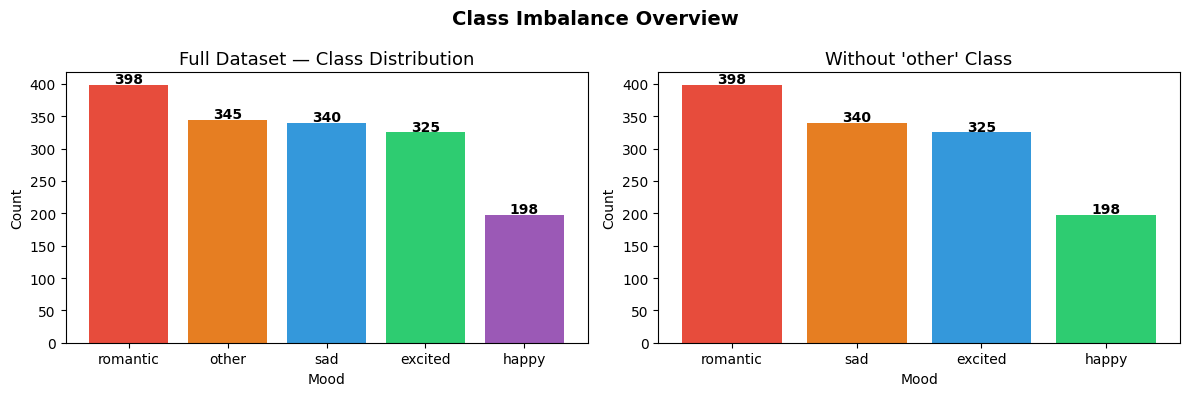

In [9]:
# ── Class distribution visualisation ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df[TARGET_COL].value_counts()
colors = ["#e74c3c", "#e67e22", "#3498db", "#2ecc71", "#9b59b6"]

axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title("Full Dataset — Class Distribution", fontsize=13)
axes[0].set_xlabel("Mood"); axes[0].set_ylabel("Count")
for i, (cls, v) in enumerate(counts.items()):
    axes[0].text(i, v + 3, str(v), ha="center", fontsize=10, fontweight="bold")

counts_no_other = df.loc[df[TARGET_COL] != "other", TARGET_COL].value_counts()
axes[1].bar(counts_no_other.index, counts_no_other.values, color=colors[:4])
axes[1].set_title("Without 'other' Class", fontsize=13)
axes[1].set_xlabel("Mood"); axes[1].set_ylabel("Count")
for i, (cls, v) in enumerate(counts_no_other.items()):
    axes[1].text(i, v + 3, str(v), ha="center", fontsize=10, fontweight="bold")

plt.suptitle("Class Imbalance Overview", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [10]:
# ── Feature selection: drop low-variance + highly correlated ──────────────
from sklearn.preprocessing import MinMaxScaler

def drop_low_variance(X_df, threshold=0.01):
    scaled = pd.DataFrame(MinMaxScaler().fit_transform(X_df), columns=X_df.columns)
    return [c for c in scaled.columns if scaled[c].var() > threshold]

def drop_correlated(X_df, threshold=0.90):
    corr  = X_df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop  = {c for c in upper.columns if any(upper[c] > threshold)}
    return [c for c in X_df.columns if c not in drop]

X_full = df[FEATURE_COLS].copy()
keep   = drop_low_variance(X_full)
X_full = X_full[keep]
keep   = drop_correlated(X_full)
X_full = X_full[keep]

print(f"Features after selection: {X_full.shape[1]}  (was {len(FEATURE_COLS)})")

y_full = df[TARGET_COL].values
INPUT_DIM = X_full.shape[1]

Features after selection: 28  (was 51)


---
## Model Architectures

### 1. MLP (Multilayer Perceptron)
A fully-connected feed-forward network with BatchNorm, Dropout, and residual-style skip connections.  
Simple but often competitive on tabular data when regularised well.

### 2. TabNet
Google's architecture for tabular data. Uses sequential attention to select relevant features at each step — acts as its own feature selector. No manual feature engineering needed.

### 3. TabTransformer
Applies transformer-style multi-head self-attention across feature embeddings, allowing the model to learn complex feature interactions. Particularly useful when features correlate meaningfully (which MFCCs do).

In [11]:
# ── MLP Architecture ──────────────────────────────────────────────────────

class MoodMLP(nn.Module):
    """
    3-layer MLP with BatchNorm + Dropout.
    Hidden dims: 256 → 128 → 64
    Skip connection from input projection to final hidden layer.
    """
    def __init__(self, input_dim, num_classes, dropout=0.3):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, 256)

        self.block1 = nn.Sequential(
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.block2 = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.block3 = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout / 2)
        )

        # skip: project input_proj output (256) down to 64 for residual add
        self.skip = nn.Linear(256, 64)

        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x0 = torch.relu(self.input_proj(x))
        x1 = self.block1(x0)
        x2 = self.block2(x1)
        x3 = self.block3(x2) + self.skip(x0)   # residual
        return self.classifier(x3)


# Quick sanity check
_dummy = torch.randn(4, INPUT_DIM)
_m     = MoodMLP(INPUT_DIM, 5)
assert _m(_dummy).shape == (4, 5)
print(f"MLP architecture OK — {sum(p.numel() for p in _m.parameters()):,} parameters")

MLP architecture OK — 132,037 parameters


In [12]:
# ── TabTransformer Architecture ───────────────────────────────────────────

class FeatureEmbedding(nn.Module):
    """Projects each scalar feature to a d_model-dim embedding."""
    def __init__(self, num_features, d_model):
        super().__init__()
        # one linear per feature  (weight sharing off — each feature has own projection)
        self.embeddings = nn.ModuleList([
            nn.Linear(1, d_model) for _ in range(num_features)
        ])

    def forward(self, x):
        # x: (B, num_features)
        # returns: (B, num_features, d_model)
        embs = [self.embeddings[i](x[:, i:i+1]) for i in range(x.shape[1])]
        return torch.stack(embs, dim=1)


class TabTransformer(nn.Module):
    """
    Transformer-based tabular model.
    Each feature is embedded → multi-head self-attention captures feature interactions
    → flattened → MLP head → class logits.

    Architecture:
        Feature Embedding  (num_features × d_model)
        → N × TransformerEncoderLayer
        → Flatten
        → LayerNorm
        → FC(256) → ReLU → Dropout
        → FC(num_classes)
    """
    def __init__(self, num_features, num_classes, d_model=32, nhead=4,
                 num_layers=2, dropout=0.1):
        super().__init__()

        assert d_model % nhead == 0, "d_model must be divisible by nhead"

        self.embedding = FeatureEmbedding(num_features, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        flat_dim = num_features * d_model
        self.norm = nn.LayerNorm(flat_dim)

        self.head = nn.Sequential(
            nn.Linear(flat_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        emb = self.embedding(x)                  # (B, F, d_model)
        out = self.transformer(emb)              # (B, F, d_model)
        out = out.flatten(1)                     # (B, F*d_model)
        out = self.norm(out)
        return self.head(out)


# Sanity check
_m2 = TabTransformer(INPUT_DIM, 5)
assert _m2(_dummy).shape == (4, 5)
print(f"TabTransformer architecture OK — {sum(p.numel() for p in _m2.parameters()):,} parameters")

TabTransformer architecture OK — 259,909 parameters


In [13]:
# ── Training helpers ──────────────────────────────────────────────────────

def get_class_weights(y_train, num_classes, device):
    """Inverse-frequency class weights for imbalanced data."""
    counts = np.bincount(y_train, minlength=num_classes).astype(float)
    weights = 1.0 / (counts + 1e-8)
    weights = weights / weights.sum() * num_classes
    return torch.tensor(weights, dtype=torch.float32).to(device)


def train_torch_model(model, X_tr, y_tr, X_te, y_te,
                      num_classes, epochs=150, batch_size=64,
                      lr=1e-3, patience=20, verbose=False):
    """
    Trains a PyTorch model with:
      - Adam optimizer + cosine annealing LR scheduler
      - Class-weighted cross-entropy loss
      - Early stopping on validation F1-macro

    Returns: (best_acc, best_f1_macro, best_f1_weighted, best_report)
    """
    model = model.to(DEVICE)

    Xtr_t = torch.tensor(X_tr, dtype=torch.float32)
    ytr_t = torch.tensor(y_tr, dtype=torch.long)
    Xte_t = torch.tensor(X_te, dtype=torch.float32).to(DEVICE)
    yte_t = torch.tensor(y_te, dtype=torch.long)

    loader = DataLoader(TensorDataset(Xtr_t, ytr_t),
                        batch_size=batch_size, shuffle=True, drop_last=False)

    cw        = get_class_weights(y_tr, num_classes, DEVICE)
    criterion = nn.CrossEntropyLoss(weight=cw)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_f1    = -1
    best_state = None
    best_report = ""
    no_improve  = 0

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        for Xb, yb in loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()

        # Validation
        model.eval()
        with torch.no_grad():
            preds = model(Xte_t).argmax(dim=1).cpu().numpy()

        f1 = f1_score(y_te, preds, average="macro", zero_division=0)

        if f1 > best_f1:
            best_f1    = f1
            best_state = copy.deepcopy(model.state_dict())
            best_preds = preds.copy()
            no_improve = 0
        else:
            no_improve += 1

        if verbose and epoch % 25 == 0:
            print(f"  Epoch {epoch:3d} | loss {epoch_loss/len(loader):.4f} | F1-macro {f1:.4f}")

        if no_improve >= patience:
            if verbose:
                print(f"  Early stop at epoch {epoch}")
            break

    # Evaluate best checkpoint
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        final_preds = model(Xte_t).argmax(dim=1).cpu().numpy()

    acc  = accuracy_score(y_te, final_preds)
    f1m  = f1_score(y_te, final_preds, average="macro",    zero_division=0)
    f1w  = f1_score(y_te, final_preds, average="weighted", zero_division=0)
    report = classification_report(y_te, final_preds, zero_division=0)

    return acc, f1m, f1w, report, final_preds


print("Training helpers defined.")

Training helpers defined.


In [14]:
# ── Data preparation helper ───────────────────────────────────────────────

def prepare_data(strategy, X, y):
    """
    Apply sampling strategy and return
    (X_train, X_test, y_train, y_test, label_encoder, num_classes).

    Strategies
    ----------
    baseline                 : raw split, no resampling
    remove_other             : drop 'other' class, then split
    oversample               : SMOTE on train set
    undersample              : RandomUnderSampler on train set
    remove_other+oversample  : remove 'other' then SMOTE
    remove_other+undersample : remove 'other' then undersample
    """
    remove_other = "remove_other" in strategy

    if remove_other:
        mask   = y != "other"
        X_use  = X[mask]
        y_use  = y[mask]
    else:
        X_use, y_use = X.copy(), y.copy()

    le    = LabelEncoder()
    y_enc = le.fit_transform(y_use)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_use.values, y_enc, test_size=0.2,
        stratify=y_enc, random_state=RANDOM_STATE
    )

    # Scale AFTER split to prevent leakage
    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_tr)
    X_te   = scaler.transform(X_te)

    if "oversample" in strategy:
        sm   = SMOTE(random_state=RANDOM_STATE)
        X_tr, y_tr = sm.fit_resample(X_tr, y_tr)
    elif "undersample" in strategy:
        rus  = RandomUnderSampler(random_state=RANDOM_STATE)
        X_tr, y_tr = rus.fit_resample(X_tr, y_tr)

    num_classes = len(le.classes_)
    return X_tr, X_te, y_tr, y_te, le, num_classes


print("Data preparation helper defined.")

Data preparation helper defined.


---
## Run Experiments

We run all **18 combinations** (3 models × 6 strategies).

| Hyperparameter | MLP | TabTransformer |
|---|---|---|
| Epochs | 150 | 150 |
| Batch size | 64 | 64 |
| LR | 1e-3 | 5e-4 |
| Early stopping patience | 20 | 20 |
| Dropout | 0.3 | 0.1 |

TabNet uses its own internal optimizer (Adam) via the `pytorch-tabnet` API.

In [15]:
# ── Main experiment loop ──────────────────────────────────────────────────

STRATEGIES = [
    "baseline",
    "remove_other",
    "oversample",
    "undersample",
    "remove_other+oversample",
    "remove_other+undersample",
]

results = []   # list of dicts, one per experiment
reports = {}   # (model_name, strategy) → classification_report string
all_preds = {} # (model_name, strategy) → (y_true, y_pred, classes)

for strategy in STRATEGIES:
    X_tr, X_te, y_tr, y_te, le, n_cls = prepare_data(strategy, X_full, y_full)

    print(f"\n{'='*65}")
    print(f"Strategy : {strategy.upper()}")
    print(f"  Train  : {len(X_tr)}  |  Test : {len(X_te)}")
    print(f"  Classes: {list(le.classes_)}")
    tr_dist = pd.Series(y_tr).value_counts().to_dict()
    print(f"  Train dist: { {le.classes_[k]: v for k, v in sorted(tr_dist.items())} }")

    # ── 1. MLP ────────────────────────────────────────────────────────────
    print("\n  [1/3] MLP", end="  ", flush=True)
    mlp = MoodMLP(INPUT_DIM, n_cls, dropout=0.3)
    acc, f1m, f1w, report, preds = train_torch_model(
        mlp, X_tr, y_tr, X_te, y_te, n_cls,
        epochs=150, batch_size=64, lr=1e-3, patience=20
    )
    print(f"→ Acc: {acc:.4f}  F1-macro: {f1m:.4f}  F1-weighted: {f1w:.4f}")
    results.append({"Model": "MLP", "Strategy": strategy,
                    "Accuracy": acc, "F1-macro": f1m, "F1-weighted": f1w})
    reports[("MLP", strategy)]    = report
    all_preds[("MLP", strategy)]  = (y_te, preds, le.classes_)

    # ── 2. TabNet ─────────────────────────────────────────────────────────
    print("  [2/3] TabNet", end="  ", flush=True)
    tabnet = TabNetClassifier(
        n_d=32, n_a=32,
        n_steps=3,
        gamma=1.3,
        n_independent=2, n_shared=2,
        momentum=0.02,
        optimizer_fn=torch.optim.Adam,
        optimizer_params={"lr": 2e-3, "weight_decay": 1e-5},
        scheduler_fn=torch.optim.lr_scheduler.CosineAnnealingLR,
        scheduler_params={"T_max": 100},
        mask_type="sparsemax",
        verbose=0,
        seed=RANDOM_STATE,
        device_name="auto"
    )

    # Class weights for TabNet
    counts_tr = np.bincount(y_tr, minlength=n_cls).astype(float)
    cw_dict   = {i: float(1.0 / (c + 1e-8)) for i, c in enumerate(counts_tr)}

    tabnet.fit(
        X_tr, y_tr,
        eval_set=[(X_te, y_te)],
        eval_name=["val"],
        eval_metric=["accuracy"],
        max_epochs=150,
        patience=20,
        batch_size=64,
        weights=cw_dict
    )

    tn_preds = tabnet.predict(X_te)
    tn_acc   = accuracy_score(y_te, tn_preds)
    tn_f1m   = f1_score(y_te, tn_preds, average="macro",    zero_division=0)
    tn_f1w   = f1_score(y_te, tn_preds, average="weighted", zero_division=0)
    tn_rpt   = classification_report(y_te, tn_preds, zero_division=0)

    print(f"→ Acc: {tn_acc:.4f}  F1-macro: {tn_f1m:.4f}  F1-weighted: {tn_f1w:.4f}")
    results.append({"Model": "TabNet", "Strategy": strategy,
                    "Accuracy": tn_acc, "F1-macro": tn_f1m, "F1-weighted": tn_f1w})
    reports[("TabNet", strategy)]   = tn_rpt
    all_preds[("TabNet", strategy)] = (y_te, tn_preds, le.classes_)

    # ── 3. TabTransformer ─────────────────────────────────────────────────
    print("  [3/3] TabTransformer", end="  ", flush=True)
    tabt = TabTransformer(INPUT_DIM, n_cls, d_model=32, nhead=4, num_layers=2, dropout=0.1)
    acc_t, f1m_t, f1w_t, report_t, preds_t = train_torch_model(
        tabt, X_tr, y_tr, X_te, y_te, n_cls,
        epochs=150, batch_size=64, lr=5e-4, patience=20
    )
    print(f"→ Acc: {acc_t:.4f}  F1-macro: {f1m_t:.4f}  F1-weighted: {f1w_t:.4f}")
    results.append({"Model": "TabTransformer", "Strategy": strategy,
                    "Accuracy": acc_t, "F1-macro": f1m_t, "F1-weighted": f1w_t})
    reports[("TabTransformer", strategy)]   = report_t
    all_preds[("TabTransformer", strategy)] = (y_te, preds_t, le.classes_)

print("\n" + "="*65)
print("All 18 experiments complete.")


Strategy : BASELINE
  Train  : 1284  |  Test : 322
  Classes: ['excited', 'happy', 'other', 'romantic', 'sad']
  Train dist: {'excited': 260, 'happy': 158, 'other': 276, 'romantic': 318, 'sad': 272}

  [1/3] MLP  → Acc: 0.4689  F1-macro: 0.4602  F1-weighted: 0.4657
  [2/3] TabNet  
Early stopping occurred at epoch 37 with best_epoch = 17 and best_val_accuracy = 0.40062
→ Acc: 0.4006  F1-macro: 0.3895  F1-weighted: 0.4051
  [3/3] TabTransformer  → Acc: 0.4938  F1-macro: 0.4737  F1-weighted: 0.4819

Strategy : REMOVE_OTHER
  Train  : 1008  |  Test : 253
  Classes: ['excited', 'happy', 'romantic', 'sad']
  Train dist: {'excited': 260, 'happy': 158, 'romantic': 318, 'sad': 272}

  [1/3] MLP  → Acc: 0.6008  F1-macro: 0.5868  F1-weighted: 0.5961
  [2/3] TabNet  
Early stopping occurred at epoch 56 with best_epoch = 36 and best_val_accuracy = 0.48617
→ Acc: 0.4862  F1-macro: 0.4572  F1-weighted: 0.4740
  [3/3] TabTransformer  → Acc: 0.6008  F1-macro: 0.5839  F1-weighted: 0.5969

Strategy : O

In [16]:
# ── Build summary dataframe ───────────────────────────────────────────────
summary = pd.DataFrame(results)

print("\n── Full Results Summary ──")
display(
    summary.sort_values(["Strategy", "F1-macro"], ascending=[True, False])
           .reset_index(drop=True)
           .style
           .background_gradient(subset=["F1-macro", "F1-weighted", "Accuracy"], cmap="YlGn")
           .format({"Accuracy": "{:.4f}", "F1-macro": "{:.4f}", "F1-weighted": "{:.4f}"})
)


── Full Results Summary ──


,Model,Strategy,Accuracy,F1-macro,F1-weighted
0,TabTransformer,baseline,0.4938,0.4737,0.4819
1,MLP,baseline,0.4689,0.4602,0.4657
2,TabNet,baseline,0.4006,0.3895,0.4051
3,TabTransformer,oversample,0.4720,0.4671,0.4749
4,MLP,oversample,0.4627,0.4532,0.4605
5,TabNet,oversample,0.4130,0.4115,0.4173
6,MLP,remove_other,0.6008,0.5868,0.5961
7,TabTransformer,remove_other,0.6008,0.5839,0.5969
8,TabNet,remove_other,0.4862,0.4572,0.4740
9,TabTransformer,remove_other+oversample,0.5929,0.5636,0.5794


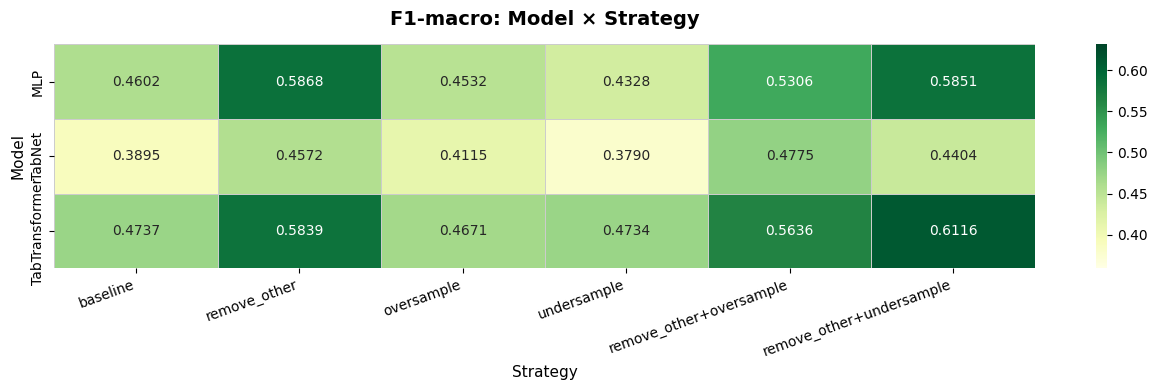

In [17]:
# ── Heatmap: F1-macro across model × strategy ─────────────────────────────
pivot = summary.pivot(index="Model", columns="Strategy", values="F1-macro")
# Reorder strategies logically
col_order = [s for s in STRATEGIES if s in pivot.columns]
pivot = pivot[col_order]

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    pivot, annot=True, fmt=".4f", cmap="YlGn",
    linewidths=0.5, linecolor="#cccccc",
    vmin=pivot.values.min() - 0.02,
    vmax=pivot.values.max() + 0.02,
    ax=ax
)
ax.set_title("F1-macro: Model × Strategy", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Strategy", fontsize=11)
ax.set_ylabel("Model", fontsize=11)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

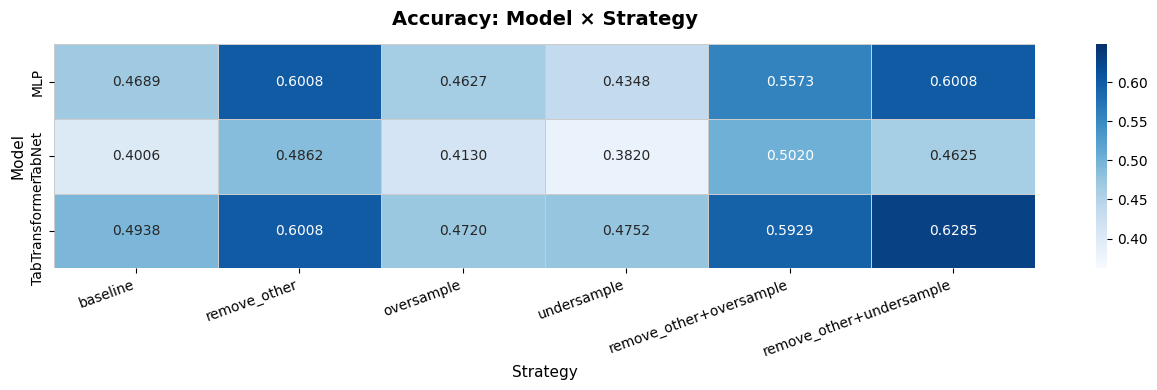

In [18]:
# ── Heatmap: Accuracy across model × strategy ─────────────────────────────
pivot_acc = summary.pivot(index="Model", columns="Strategy", values="Accuracy")[col_order]

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    pivot_acc, annot=True, fmt=".4f", cmap="Blues",
    linewidths=0.5, linecolor="#cccccc",
    vmin=pivot_acc.values.min() - 0.02,
    vmax=pivot_acc.values.max() + 0.02,
    ax=ax
)
ax.set_title("Accuracy: Model × Strategy", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Strategy", fontsize=11)
ax.set_ylabel("Model", fontsize=11)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

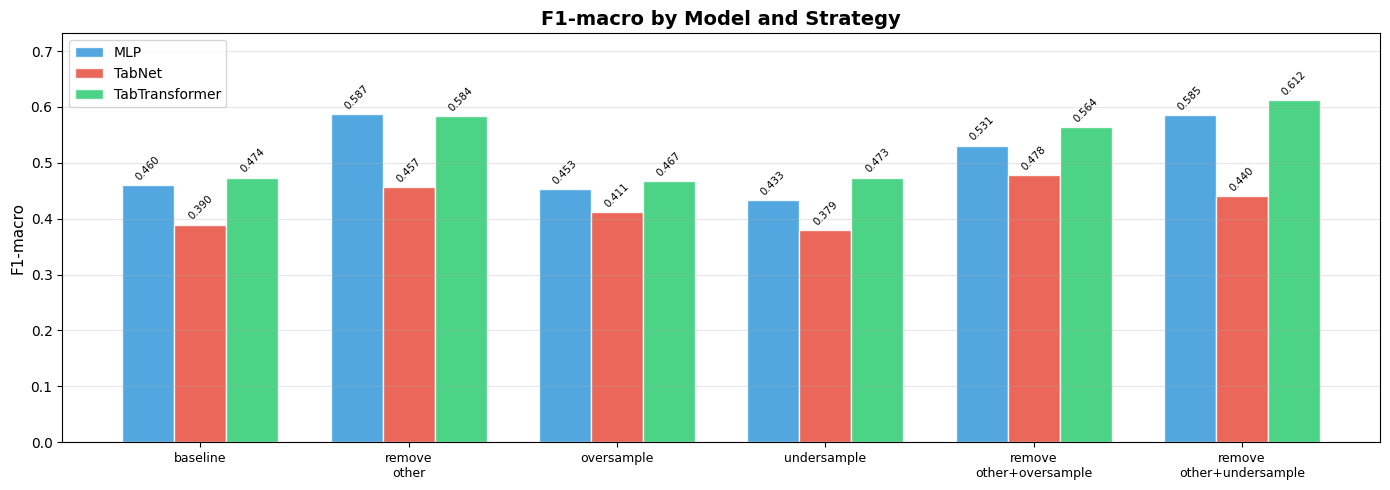

In [19]:
# ── Grouped bar chart: F1-macro by model, grouped by strategy ─────────────
models     = summary["Model"].unique()
strategies = STRATEGIES
x          = np.arange(len(strategies))
width      = 0.25
model_colors = {"MLP": "#3498db", "TabNet": "#e74c3c", "TabTransformer": "#2ecc71"}

fig, ax = plt.subplots(figsize=(14, 5))
for i, model in enumerate(models):
    vals = [summary.loc[(summary.Model == model) &
                         (summary.Strategy == s), "F1-macro"].values[0]
            for s in strategies]
    bars = ax.bar(x + i * width, vals, width, label=model,
                  color=model_colors[model], alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005, f"{v:.3f}",
                ha="center", va="bottom", fontsize=7.5, rotation=45)

ax.set_xticks(x + width)
ax.set_xticklabels([s.replace("_", "\n") for s in strategies], fontsize=9)
ax.set_ylabel("F1-macro", fontsize=11)
ax.set_title("F1-macro by Model and Strategy", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.set_ylim(0, min(1.0, summary["F1-macro"].max() + 0.12))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# ── Top 5 configurations ──────────────────────────────────────────────────
top5 = summary.sort_values("F1-macro", ascending=False).head(5).reset_index(drop=True)
top5.index += 1
print("Top 5 Model × Strategy Combinations (by F1-macro)\n")
display(
    top5.style
        .background_gradient(subset=["F1-macro", "F1-weighted", "Accuracy"], cmap="YlGn")
        .format({"Accuracy": "{:.4f}", "F1-macro": "{:.4f}", "F1-weighted": "{:.4f}"})
)

Top 5 Model × Strategy Combinations (by F1-macro)



,Model,Strategy,Accuracy,F1-macro,F1-weighted
1,TabTransformer,remove_other+undersample,0.6285,0.6116,0.6288
2,MLP,remove_other,0.6008,0.5868,0.5961
3,MLP,remove_other+undersample,0.6008,0.5851,0.5998
4,TabTransformer,remove_other,0.6008,0.5839,0.5969
5,TabTransformer,remove_other+oversample,0.5929,0.5636,0.5794


In [21]:
# ── Per-class classification report for the best configuration ────────────
best_row      = summary.loc[summary["F1-macro"].idxmax()]
best_model    = best_row["Model"]
best_strategy = best_row["Strategy"]

print(f"Best configuration: {best_model}  |  Strategy: {best_strategy}")
print(f"F1-macro: {best_row['F1-macro']:.4f}   Accuracy: {best_row['Accuracy']:.4f}\n")
print("Per-class Classification Report:")
print(reports[(best_model, best_strategy)])

Best configuration: TabTransformer  |  Strategy: remove_other+undersample
F1-macro: 0.6116   Accuracy: 0.6285

Per-class Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.82      0.81        65
           1       0.40      0.42      0.41        40
           2       0.57      0.54      0.55        80
           3       0.68      0.68      0.68        68

    accuracy                           0.63       253
   macro avg       0.61      0.61      0.61       253
weighted avg       0.63      0.63      0.63       253



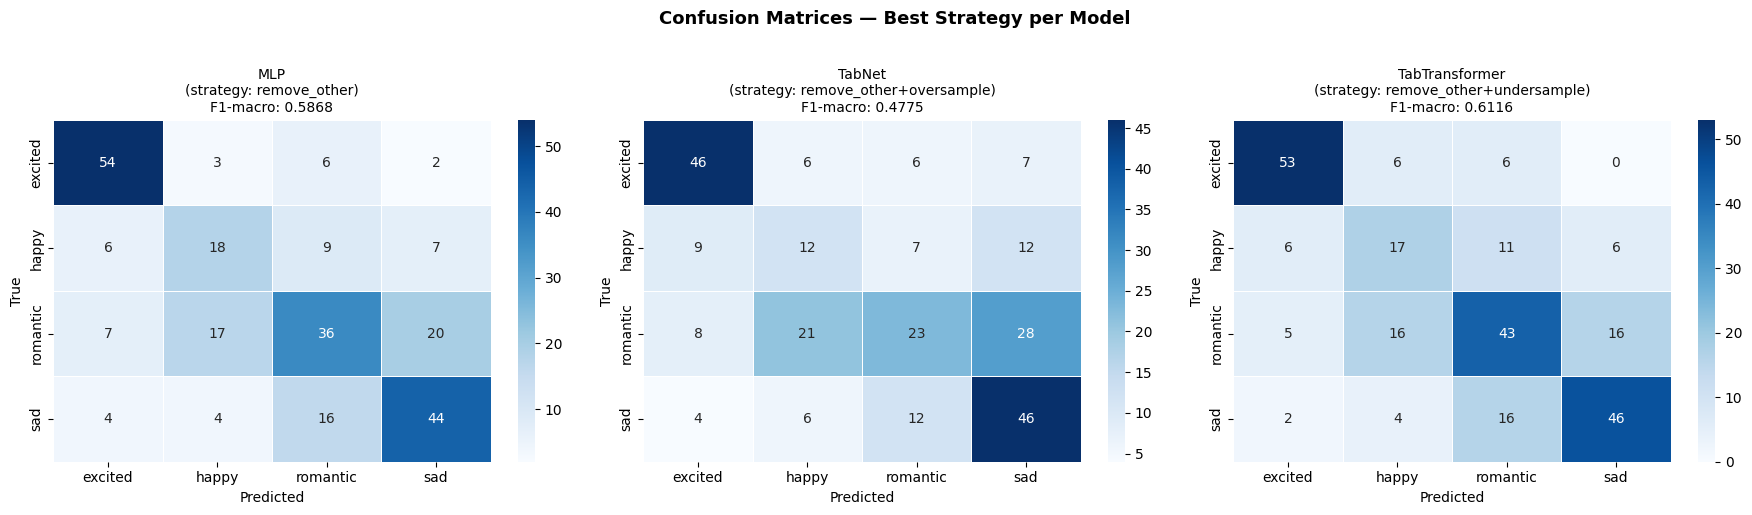

In [22]:
# ── Confusion matrices for all 3 models (best strategy per model) ─────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model_name in zip(axes, ["MLP", "TabNet", "TabTransformer"]):
    # Pick the best strategy for this model
    best_strat = (
        summary[summary.Model == model_name]
        .sort_values("F1-macro", ascending=False)
        .iloc[0]["Strategy"]
    )
    y_true, y_pred, classes = all_preds[(model_name, best_strat)]
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=classes, yticklabels=classes,
        linewidths=0.5, ax=ax
    )
    f1_val = summary.loc[(summary.Model == model_name) &
                          (summary.Strategy == best_strat), "F1-macro"].values[0]
    ax.set_title(f"{model_name}\n(strategy: {best_strat})\nF1-macro: {f1_val:.4f}",
                 fontsize=10)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")

plt.suptitle("Confusion Matrices — Best Strategy per Model",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

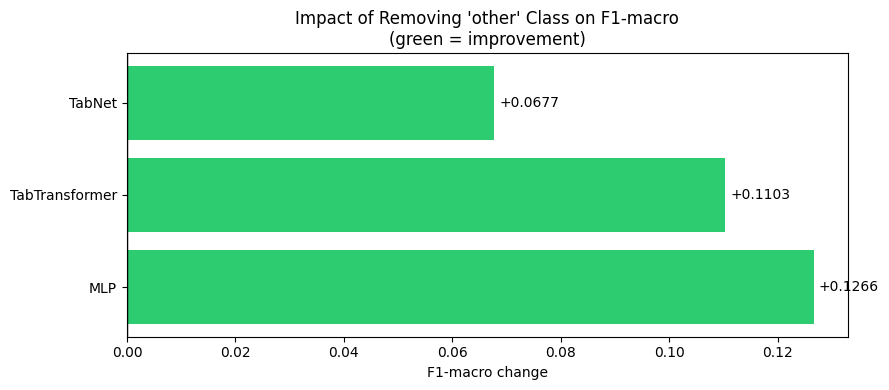


Delta F1-macro (remove_other - baseline):
Model
MLP              0.1266
TabTransformer   0.1103
TabNet           0.0677


In [23]:
# ── Impact analysis: removing 'other' class ───────────────────────────────
baseline_f1   = summary[summary.Strategy == "baseline"].set_index("Model")["F1-macro"]
no_other_f1   = summary[summary.Strategy == "remove_other"].set_index("Model")["F1-macro"]
delta_other   = (no_other_f1 - baseline_f1).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in delta_other.values]
ax.barh(delta_other.index, delta_other.values, color=bar_colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("F1-macro change")
ax.set_title("Impact of Removing 'other' Class on F1-macro\n(green = improvement)")
for i, v in enumerate(delta_other.values):
    ax.text(v + (0.001 if v >= 0 else -0.001), i, f"{v:+.4f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=10)
plt.tight_layout()
plt.show()

print("\nDelta F1-macro (remove_other - baseline):")
print(delta_other.to_string())

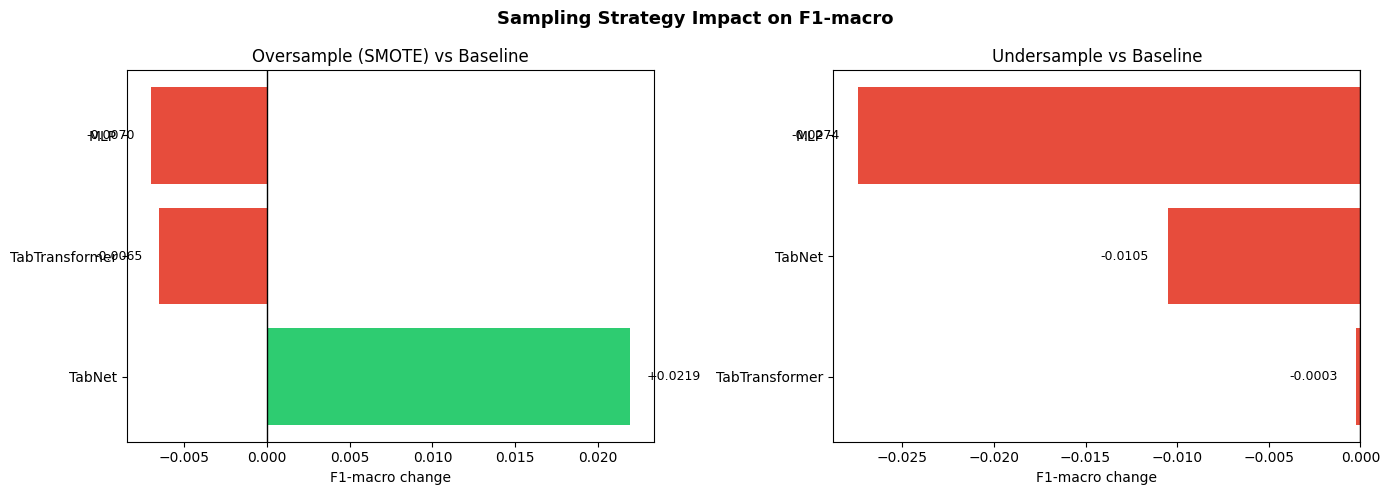

In [24]:
# ── Impact analysis: sampling strategies vs baseline ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, compare_strat, title in [
    (axes[0], "oversample",  "Oversample (SMOTE) vs Baseline"),
    (axes[1], "undersample", "Undersample vs Baseline"),
]:
    ref  = summary[summary.Strategy == "baseline"].set_index("Model")["F1-macro"]
    comp = summary[summary.Strategy == compare_strat].set_index("Model")["F1-macro"]
    delta = (comp - ref).sort_values(ascending=False)
    colors_bar = ["#2ecc71" if v >= 0 else "#e74c3c" for v in delta.values]
    ax.barh(delta.index, delta.values, color=colors_bar)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("F1-macro change")
    ax.set_title(title)
    for i, v in enumerate(delta.values):
        ax.text(v + (0.001 if v >= 0 else -0.001), i, f"{v:+.4f}",
                va="center", ha="left" if v >= 0 else "right", fontsize=9)

plt.suptitle("Sampling Strategy Impact on F1-macro", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [25]:
# ── Per-model best strategy summary ──────────────────────────────────────
best_per_model = (
    summary.sort_values("F1-macro", ascending=False)
           .groupby("Model", sort=False)
           .first()
           .reset_index()[["Model", "Strategy", "F1-macro", "F1-weighted", "Accuracy"]]
)

print("Best strategy per model:\n")
display(
    best_per_model.style
        .background_gradient(subset=["F1-macro", "F1-weighted", "Accuracy"], cmap="YlGn")
        .format({"Accuracy": "{:.4f}", "F1-macro": "{:.4f}", "F1-weighted": "{:.4f}"})
)

Best strategy per model:



,Model,Strategy,F1-macro,F1-weighted,Accuracy
0,TabTransformer,remove_other+undersample,0.6116,0.6288,0.6285
1,MLP,remove_other,0.5868,0.5961,0.6008
2,TabNet,remove_other+oversample,0.4775,0.4909,0.5020


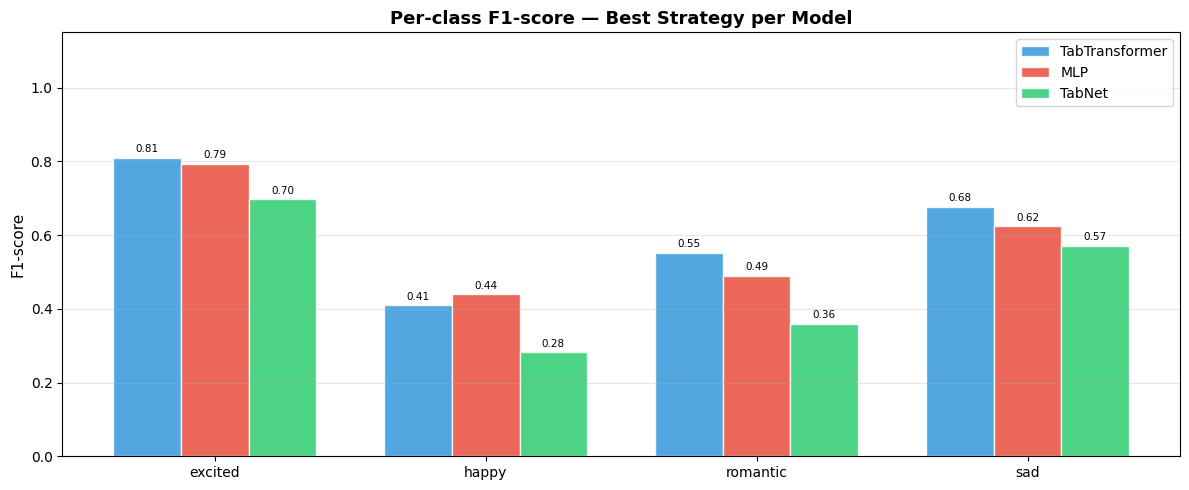

In [26]:
# ── Radar chart: per-class F1 for best config of each model ───────────────
# Get all unique classes across best strategies
from sklearn.metrics import classification_report as cr

def per_class_f1(model_name, strategy):
    y_true, y_pred, classes = all_preds[(model_name, strategy)]
    rep = cr(y_true, y_pred, target_names=classes, output_dict=True, zero_division=0)
    return {cls: rep[cls]["f1-score"] for cls in classes if cls in rep}

model_best_strat = {
    row["Model"]: row["Strategy"]
    for _, row in best_per_model.iterrows()
}

# Collect per-class F1 for each model's best strategy
all_classes = sorted(set(
    cls
    for m, s in model_best_strat.items()
    for cls in per_class_f1(m, s).keys()
))

per_class_data = {
    model: per_class_f1(model, strat)
    for model, strat in model_best_strat.items()
}

# Grouped bar
x       = np.arange(len(all_classes))
n_m     = len(per_class_data)
w       = 0.25
pal     = ["#3498db", "#e74c3c", "#2ecc71"]

fig, ax = plt.subplots(figsize=(12, 5))
for i, (model, class_f1) in enumerate(per_class_data.items()):
    vals = [class_f1.get(c, 0) for c in all_classes]
    bars = ax.bar(x + i * w, vals, w, label=model, color=pal[i], alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01, f"{v:.2f}",
                ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x + w)
ax.set_xticklabels(all_classes, fontsize=10)
ax.set_ylabel("F1-score", fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_title("Per-class F1-score — Best Strategy per Model",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# ── Save all results ──────────────────────────────────────────────────────
summary.to_csv("neural_experiment_results.csv", index=False)
print("Saved → neural_experiment_results.csv")
print()
print("Final summary (sorted by F1-macro):")
display(
    summary.sort_values("F1-macro", ascending=False)
           .reset_index(drop=True)
           .style
           .background_gradient(subset=["F1-macro", "F1-weighted", "Accuracy"], cmap="YlGn")
           .format({"Accuracy": "{:.4f}", "F1-macro": "{:.4f}", "F1-weighted": "{:.4f}"})
)

Saved → neural_experiment_results.csv

Final summary (sorted by F1-macro):


,Model,Strategy,Accuracy,F1-macro,F1-weighted
0,TabTransformer,remove_other+undersample,0.6285,0.6116,0.6288
1,MLP,remove_other,0.6008,0.5868,0.5961
2,MLP,remove_other+undersample,0.6008,0.5851,0.5998
3,TabTransformer,remove_other,0.6008,0.5839,0.5969
4,TabTransformer,remove_other+oversample,0.5929,0.5636,0.5794
5,MLP,remove_other+oversample,0.5573,0.5306,0.5529
6,TabNet,remove_other+oversample,0.5020,0.4775,0.4909
7,TabTransformer,baseline,0.4938,0.4737,0.4819
8,TabTransformer,undersample,0.4752,0.4734,0.4781
9,TabTransformer,oversample,0.4720,0.4671,0.4749
